# Student Performance Analysis and Academic Insights

**Dataset:** `student_data.csv` — 395 secondary-school students from two Portuguese schools  
**Target variable:** `G3` — final grade on a 0–20 scale  
**Purpose:** Explore factors associated with final student performance using a structured four-level framework: Observations → Insights → Hypotheses → Recommendations  

---

**Analytical framework used throughout this notebook:**
- **Observation** — a direct, factual description of what the data shows
- **Insight** — a meaningful pattern derived from one or more observations
- **Hypothesis** — a plausible, testable explanation for an insight
- **Recommendation** — a practical action grounded in evidence, labelled by evidence strength

> The original `student_data.csv` is not modified at any point in this notebook.

---
## Section 1 — Data Loading and Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

RANDOM_STATE = 42

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 120
plt.rcParams['figure.figsize'] = (9, 5)

os.makedirs('figures', exist_ok=True)

# Load dataset — read-only, never modified
df = pd.read_csv('student_data.csv')

print('Shape:', df.shape)
df.head()

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### 1.1 Column Overview

The 33 columns fall into three groups:

| Group | Columns |
|---|---|
| **Ordinal integers** (coded scale) | `studytime` (1–4), `traveltime` (1–4), `failures` (0–3), `Medu` (0–4), `Fedu` (0–4), `famrel` (1–5), `freetime` (1–5), `goout` (1–5), `Dalc` (1–5), `Walc` (1–5), `health` (1–5) |
| **Nominal categoricals** | `school`, `sex`, `address`, `famsize`, `Pstatus`, `Mjob`, `Fjob`, `reason`, `guardian`, `schoolsup`, `famsup`, `paid`, `activities`, `nursery`, `higher`, `internet`, `romantic` |
| **Numeric** | `age`, `absences`, `G1`, `G2`, `G3` |

**Ordinal encoding keys used in all charts and text:**
- `studytime`: 1 = "<2h/wk", 2 = "2–5h/wk", 3 = "5–10h/wk", 4 = ">10h/wk"
- `Medu` / `Fedu`: 0 = "None", 1 = "Primary (4th)", 2 = "Primary (9th)", 3 = "Secondary", 4 = "Higher Ed."
- `failures`: number of past class failures (where 3 means ≥ 3)

In [2]:
print('Data types:')
print(df.dtypes)
print('\nNull counts per column:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Data types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

Null counts per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0



Duplicate rows: 0


**Observation:** No missing values detected in any column. No duplicate rows detected.

In [3]:
# Categorical and binary column value counts
cat_cols = [
    'school', 'sex', 'address', 'famsize', 'Pstatus',
    'Mjob', 'Fjob', 'reason', 'guardian',
    'schoolsup', 'famsup', 'paid', 'activities',
    'nursery', 'higher', 'internet', 'romantic'
]
for col in cat_cols:
    print(f'{col}:\n{df[col].value_counts().to_string()}\n')

school:
school
GP    349
MS     46

sex:
sex
F    208
M    187

address:
address
U    307
R     88

famsize:
famsize
GT3    281
LE3    114

Pstatus:
Pstatus
T    354
A     41

Mjob:
Mjob
other       141
services    103
at_home      59
teacher      58
health       34

Fjob:
Fjob
other       217
services    111
teacher      29
at_home      20
health       18

reason:
reason
course        145
home          109
reputation    105
other          36

guardian:
guardian
mother    273
father     90
other      32

schoolsup:
schoolsup
no     344
yes     51

famsup:
famsup
yes    242
no     153

paid:
paid
no     214
yes    181

activities:
activities
yes    201
no     194

nursery:
nursery
yes    314
no      81

higher:
higher
yes    375
no      20

internet:
internet
yes    329
no      66

romantic:
romantic
no     263
yes    132



**Observation:** Two notable imbalances:
- `school`: GP = 349, MS = 46 — the dataset is dominated by one school.
- `higher` (aspiration to pursue higher education): yes = 375, no = 20 — the vast majority aspire to higher education.

In [4]:
# Grade statistics
print('Grade summary (G1, G2, G3):')
print(df[['G1', 'G2', 'G3']].describe().round(2))
print(f'\nG1 zeros: {(df["G1"] == 0).sum()}')
print(f'G2 zeros: {(df["G2"] == 0).sum()}')
print(f'G3 zeros: {(df["G3"] == 0).sum()}')

Grade summary (G1, G2, G3):
           G1      G2      G3
count  395.00  395.00  395.00
mean    10.91   10.71   10.42
std      3.32    3.76    4.58
min      3.00    0.00    0.00
25%      8.00    9.00    8.00
50%     11.00   11.00   11.00
75%     13.00   13.00   14.00
max     19.00   19.00   20.00

G1 zeros: 0
G2 zeros: 13
G3 zeros: 38


**Observation:** G3 ranges from 0 to 20 (mean ≈ 10.42, std ≈ 4.58). G3 = 0 is recorded for 38 students; G2 = 0 appears in 13 rows; G1 has no zero values. All 38 students with G3 = 0 have a non-zero G1 (first-period grade), making this a pattern distinct from missing data. The reason for G3 = 0 is not documented in the dataset and is treated as an observation only.

In [5]:
# G3=0 rows: show G1 and G2 alongside
g3_zero = df[df['G3'] == 0][['G1', 'G2', 'G3']].reset_index(drop=True)
print(f'Rows where G3 = 0 ({len(g3_zero)} students):')
print(g3_zero.to_string())

Rows where G3 = 0 (38 students):
    G1  G2  G3
0    7   4   0
1   12   0   0
2    8   0   0
3    9   0   0
4   11   0   0
5   10   0   0
6    4   0   0
7    7   9   0
8    5   0   0
9    6   7   0
10   7   6   0
11   6   5   0
12   5   0   0
13   7   6   0
14   7   0   0
15   6   7   0
16   6   5   0
17   8   7   0
18   6   5   0
19   7   7   0
20   6   0   0
21   7   0   0
22  10   9   0
23   9  10   0
24   6   0   0
25  10   9   0
26   9   9   0
27   8   8   0
28   7   0   0
29   8   8   0
30  10   9   0
31   7   8   0
32  10  10   0
33   9   8   0
34   7   6   0
35   6   5   0
36   7   5   0
37   6   5   0


In [6]:
# Absences statistics
print('Absences summary:')
print(df['absences'].describe().round(2))
print(f'\nStudents with absences > 30: {(df["absences"] > 30).sum()}')
print('\nRows with absences > 30:')
print(df[df['absences'] > 30][['absences', 'G3']].sort_values('absences', ascending=False).to_string())

Absences summary:
count    395.00
mean       5.71
std        8.00
min        0.00
25%        0.00
50%        4.00
75%        8.00
max       75.00
Name: absences, dtype: float64

Students with absences > 30: 5

Rows with absences > 30:
     absences  G3
276        75   9
183        56   8
74         54  11
315        40  11
307        38   8


**Observation:** `absences` ranges from 0 to 75 with a mean of approximately 5.71 and a median of 4. The distribution is heavily right-skewed (75% of students have 8 or fewer absences). Five students have more than 30 absences; the maximum is 75.

In [7]:
# Ordinal variable distributions
ordinal_cols = {
    'failures': 'Prior Failures',
    'studytime': 'Weekly Study Time (1–4)',
    'Medu': 'Maternal Education (0–4)'
}
for col, label in ordinal_cols.items():
    print(f'{label}:')
    print(df[col].value_counts().sort_index().to_string())
    print()

Prior Failures:
failures
0    312
1     50
2     17
3     16

Weekly Study Time (1–4):
studytime
1    105
2    198
3     65
4     27

Maternal Education (0–4):
Medu
0      3
1     59
2    103
3     99
4    131



**Data quality summary:** The dataset is complete — 395 rows × 33 columns, no missing values, no duplicate rows. Two distributional observations are carried forward: (1) 38 rows with G3 = 0, all with non-zero G1, cause undocumented; (2) heavily right-skewed absences with extreme values up to 75. No rows or values have been modified.

---

## Section 2 — Exploratory Data Analysis

Five targeted charts, each followed by an **Observation** cell. Observation cells contain only factual descriptions of what the chart shows — no causal claims, no interpretations.

### Chart 1 — Distribution of Final Grade (G3)

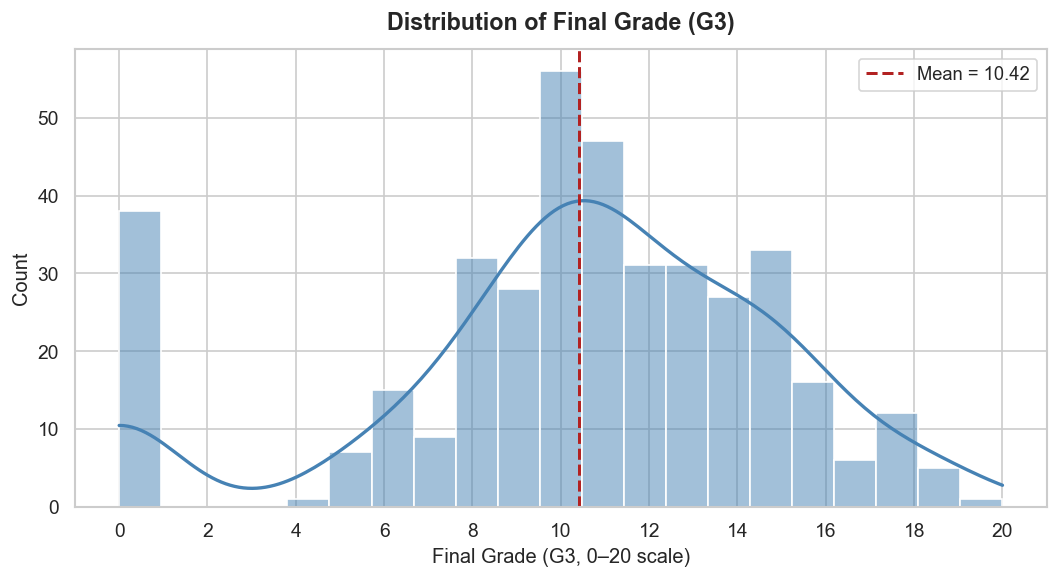

G3 — Mean: 10.42, Median: 11.0, Std: 4.58


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(df['G3'], bins=21, kde=True, color='steelblue',
             line_kws={'linewidth': 2}, ax=ax)

mean_g3 = df['G3'].mean()
ax.axvline(mean_g3, color='firebrick', linestyle='--', linewidth=1.8,
           label=f'Mean = {mean_g3:.2f}')

ax.set_title('Distribution of Final Grade (G3)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Final Grade (G3, 0–20 scale)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('figures/chart1_g3_distribution.png')
plt.show()
print(f'G3 — Mean: {mean_g3:.2f}, Median: {df["G3"].median():.1f}, Std: {df["G3"].std():.2f}')

**Observation (Chart 1):** G3 is roughly bell-shaped and centred around a mean of approximately 10.42 and a median of 11. A visible spike at G3 = 0 represents 38 students with a recorded final grade of zero, which sits apart from the main distribution. The bulk of scores fall between approximately 7 and 16. The G3 = 0 spike introduces a slight left tail.

### Chart 2 — G3 by Number of Prior Failures

C:\Users\Admin\AppData\Local\Temp\ipykernel_17308\2930853166.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='failures', y='G3', order=[0, 1, 2, 3],
C:\Users\Admin\AppData\Local\Temp\ipykernel_17308\2930853166.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, fontsize=11)


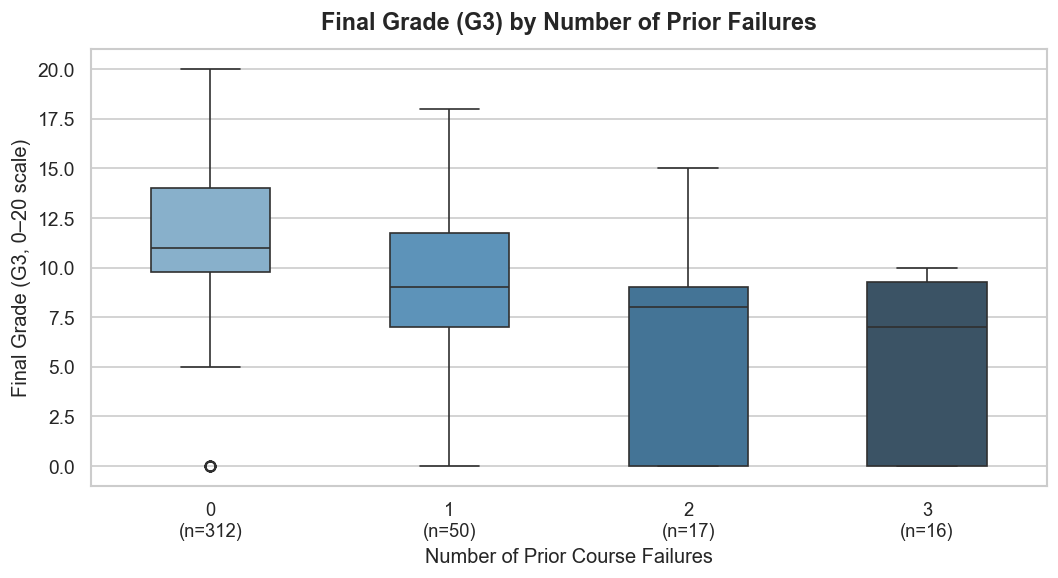

Median G3 by failures:
failures
0    11.0
1     9.0
2     8.0
3     7.0


In [9]:
failure_counts = df['failures'].value_counts().sort_index()
x_labels = [f'{v}\n(n={failure_counts[v]})' for v in [0, 1, 2, 3]]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='failures', y='G3', order=[0, 1, 2, 3],
            palette='Blues_d', width=0.5, ax=ax)

ax.set_xticklabels(x_labels, fontsize=11)
ax.set_title('Final Grade (G3) by Number of Prior Failures', fontsize=14,
             fontweight='bold', pad=12)
ax.set_xlabel('Number of Prior Course Failures', fontsize=12)
ax.set_ylabel('Final Grade (G3, 0–20 scale)', fontsize=12)

plt.tight_layout()
plt.savefig('figures/chart2_failures_vs_g3.png')
plt.show()

print('Median G3 by failures:')
print(df.groupby('failures')['G3'].median().to_string())

**Observation (Chart 2):** The median G3 is lower for students with more prior failures. Students with 0 prior failures (n = 312) have a median G3 of 11. The median declines to 9 at 1 failure (n = 50), 8 at 2 failures (n = 17), and 7 at 3 failures (n = 16). The interquartile range widens for higher failure counts. The groups with 2 or 3 failures are small (n = 17 and n = 16) and should be interpreted with caution.

### Chart 3 — G3 by Weekly Study Time

C:\Users\Admin\AppData\Local\Temp\ipykernel_17308\1187407770.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='studytime', y='G3', order=[1, 2, 3, 4],
C:\Users\Admin\AppData\Local\Temp\ipykernel_17308\1187407770.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(st_labels, fontsize=11)


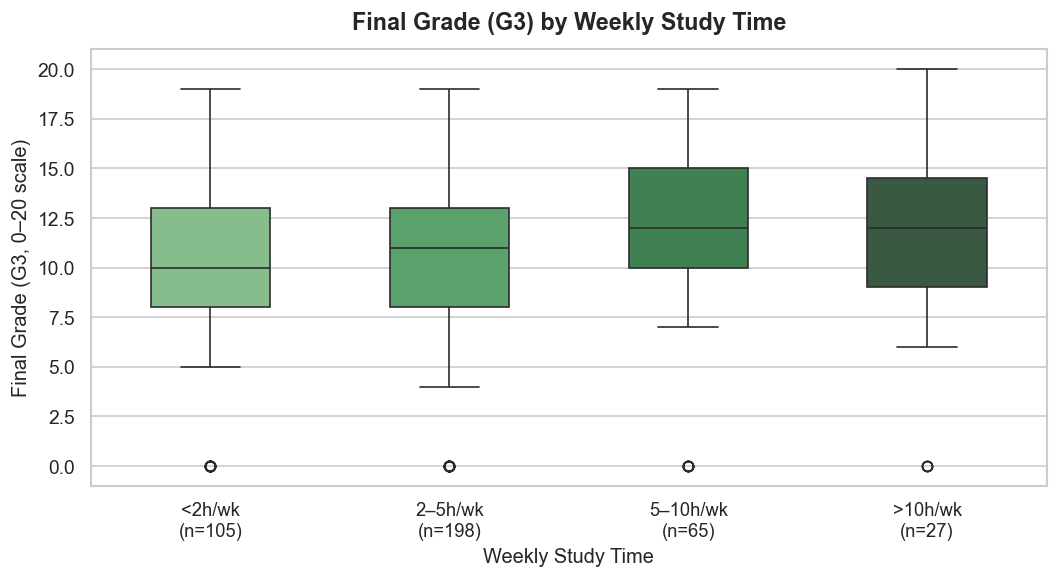

Median G3 by studytime:
studytime
1    10.0
2    11.0
3    12.0
4    12.0


In [10]:
studytime_map = {1: '<2h/wk', 2: '2–5h/wk', 3: '5–10h/wk', 4: '>10h/wk'}
studytime_counts = df['studytime'].value_counts().sort_index()
st_labels = [f'{studytime_map[v]}\n(n={studytime_counts[v]})' for v in [1, 2, 3, 4]]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='studytime', y='G3', order=[1, 2, 3, 4],
            palette='Greens_d', width=0.5, ax=ax)

ax.set_xticklabels(st_labels, fontsize=11)
ax.set_title('Final Grade (G3) by Weekly Study Time', fontsize=14,
             fontweight='bold', pad=12)
ax.set_xlabel('Weekly Study Time', fontsize=12)
ax.set_ylabel('Final Grade (G3, 0–20 scale)', fontsize=12)

plt.tight_layout()
plt.savefig('figures/chart3_studytime_vs_g3.png')
plt.show()

print('Median G3 by studytime:')
print(df.groupby('studytime')['G3'].median().to_string())

**Observation (Chart 3):** Median G3 is higher for students reporting more weekly study time. Students in the lowest band (< 2h/wk, n = 105) have a median G3 of 10; the median rises to 11 at 2–5h/wk (n = 198) and reaches 12 at both the 5–10h/wk (n = 65) and > 10h/wk (n = 27) bands. The interquartile range is wide at all levels, indicating substantial grade variation within each group. Study time alone does not cleanly separate high from low performers.

### Chart 4 — Mean G3 by Maternal Education Level

C:\Users\Admin\AppData\Local\Temp\ipykernel_17308\3545376482.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Medu', y='G3', order=[0, 1, 2, 3, 4],


C:\Users\Admin\AppData\Local\Temp\ipykernel_17308\3545376482.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([medu_map[v] for v in [0, 1, 2, 3, 4]], fontsize=10)


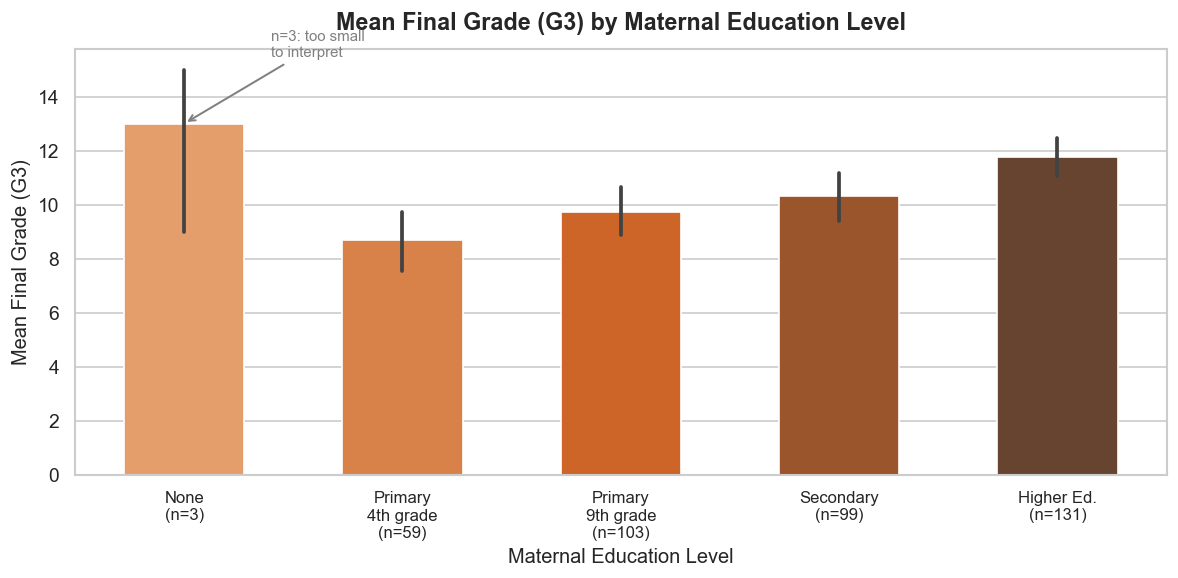

Mean G3 by Medu:
       mean  count
Medu              
0     13.00      3
1      8.68     59
2      9.73    103
3     10.30     99
4     11.76    131


In [11]:
medu_counts = df['Medu'].value_counts().sort_index()
medu_map = {
    0: f'None\n(n={medu_counts[0]})',
    1: f'Primary\n4th grade\n(n={medu_counts[1]})',
    2: f'Primary\n9th grade\n(n={medu_counts[2]})',
    3: f'Secondary\n(n={medu_counts[3]})',
    4: f'Higher Ed.\n(n={medu_counts[4]})'
}

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df, x='Medu', y='G3', order=[0, 1, 2, 3, 4],
            estimator='mean', errorbar=('ci', 95),
            palette='Oranges_d', width=0.55, ax=ax)

ax.set_xticklabels([medu_map[v] for v in [0, 1, 2, 3, 4]], fontsize=10)
ax.set_title('Mean Final Grade (G3) by Maternal Education Level',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Maternal Education Level', fontsize=12)
ax.set_ylabel('Mean Final Grade (G3)', fontsize=12)

# Annotate Medu=0 as very small group
medu0_mean = df[df['Medu'] == 0]['G3'].mean()
ax.annotate('n=3: too small\nto interpret',
            xy=(0, medu0_mean),
            xytext=(0.4, medu0_mean + 2.5),
            fontsize=9, color='grey',
            arrowprops=dict(arrowstyle='->', color='grey', lw=1.2))

plt.tight_layout()
plt.savefig('figures/chart4_medu_vs_g3.png')
plt.show()

print('Mean G3 by Medu:')
print(df.groupby('Medu')['G3'].agg(['mean', 'count']).round(2).to_string())

**Observation (Chart 4):** Among the well-populated groups, mean G3 is lowest at Medu = 1 (Primary 4th grade, n = 59, mean ≈ 8.68) and highest at Medu = 4 (Higher Education, n = 131, mean ≈ 11.76). Mean G3 increases progressively from Medu = 1 through Medu = 4. The Medu = 0 group (n = 3) is too small to interpret and is excluded from this comparison. The 95% confidence intervals overlap between adjacent levels, indicating that the difference between neighbouring levels is not large relative to within-group variation.

### Chart 5 — Absences vs. Final Grade (G3)

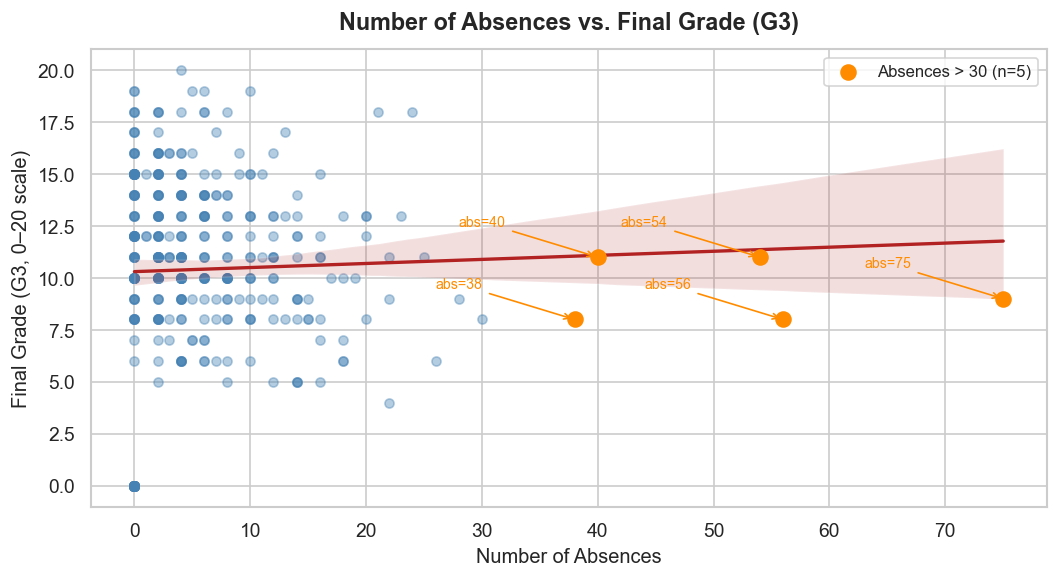

Pearson correlation (absences, G3): 0.034


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.regplot(data=df, x='absences', y='G3',
            scatter_kws={'alpha': 0.4, 'color': 'steelblue', 's': 30},
            line_kws={'color': 'firebrick', 'linewidth': 2},
            ax=ax)

extreme = df[df['absences'] > 30]
ax.scatter(extreme['absences'], extreme['G3'],
           color='darkorange', s=80, zorder=5,
           label=f'Absences > 30 (n={len(extreme)})')
for _, row in extreme.iterrows():
    ax.annotate(f"abs={int(row['absences'])}",
                xy=(row['absences'], row['G3']),
                xytext=(row['absences'] - 12, row['G3'] + 1.5),
                fontsize=8.5, color='darkorange',
                arrowprops=dict(arrowstyle='->', color='darkorange', lw=1))

ax.set_title('Number of Absences vs. Final Grade (G3)', fontsize=14,
             fontweight='bold', pad=12)
ax.set_xlabel('Number of Absences', fontsize=12)
ax.set_ylabel('Final Grade (G3, 0–20 scale)', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('figures/chart5_absences_vs_g3.png')
plt.show()

corr_abs = df['absences'].corr(df['G3'])
print(f'Pearson correlation (absences, G3): {corr_abs:.3f}')

**Observation (Chart 5):** The scatter plot shows a wide spread of G3 values across all absence levels. The regression line is nearly flat (Pearson r ≈ 0.034, printed above), indicating very little linear association between absences and G3 in this dataset. Variance is high throughout. Five students with absences > 30 are highlighted; their G3 values range from 8 to 11. The near-zero correlation means absences should not be described as a reliable indicator of G3 based on this data alone.

### Chart 6 — Correlation Heatmap (Reference)

> **Note on G1 and G2:** These are included in the heatmap below for reference only, to show their strong association with G3. They are **excluded from the machine learning model** in Section 4 — see that section for the full explanation.

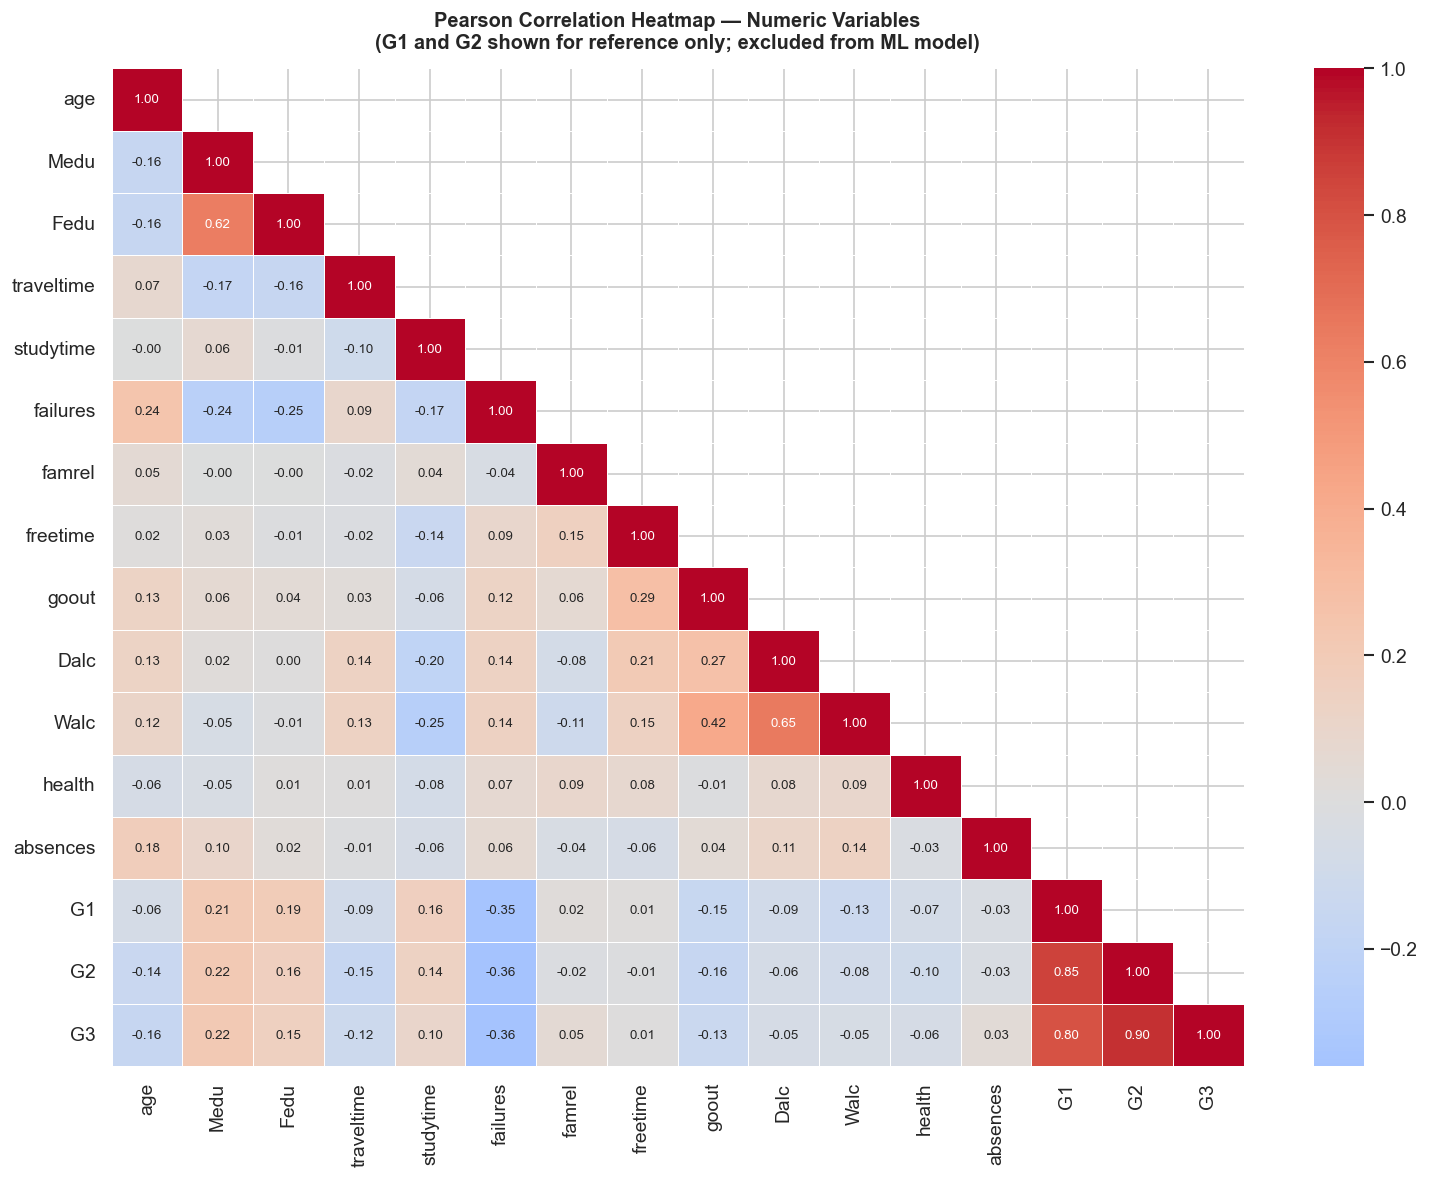

Correlations with G3 (all numeric variables, sorted):
G2            0.905
G1            0.801
Medu          0.217
Fedu          0.152
studytime     0.098
famrel        0.051
absences      0.034
freetime      0.011
Walc         -0.052
Dalc         -0.055
health       -0.061
traveltime   -0.117
goout        -0.133
age          -0.162
failures     -0.360


In [13]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 8}, ax=ax)

ax.set_title('Pearson Correlation Heatmap — Numeric Variables\n'
             '(G1 and G2 shown for reference only; excluded from ML model)',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('figures/chart6_correlation_heatmap.png')
plt.show()

print('Correlations with G3 (all numeric variables, sorted):')
print(corr_matrix['G3'].drop('G3').sort_values(ascending=False).round(3).to_string())

**Observation (Chart 6):** G2 has by far the strongest linear association with G3 (r ≈ 0.905), followed by G1 (r ≈ 0.801). Among non-grade numeric variables, `failures` shows the strongest association with G3 (r ≈ −0.360, negative). `Medu` is the strongest positive non-grade correlate (r ≈ 0.217). `absences` has a near-zero linear correlation with G3 (r ≈ 0.034). Most lifestyle variables (goout, Dalc, Walc) show weak negative associations.

---

## Section 3 — Observations, Insights, Hypotheses, and Recommendations

This section applies the four-level analytical framework to the EDA findings.

In [14]:
# Compute all key statistics referenced in the text below
mean_g3   = df['G3'].mean()
median_g3 = df['G3'].median()
std_g3    = df['G3'].std()

med_by_failures  = df.groupby('failures')['G3'].median()
med_by_studytime = df.groupby('studytime')['G3'].median()
mean_by_medu     = df.groupby('Medu')['G3'].agg(['mean', 'count'])

corr_g3 = df.select_dtypes(include='number').corr()['G3'].drop('G3').sort_values(ascending=False)

print(f'G3 — Mean: {mean_g3:.2f}, Median: {median_g3:.1f}, Std: {std_g3:.2f}')
print(f'\nG3=0 rows: {(df["G3"]==0).sum()}')
print(f'All G3=0 rows have non-zero G1: {(df[df["G3"]==0]["G1"] != 0).all()}')
print(f'\nMedian G3 by failures:\n{med_by_failures.to_string()}')
print(f'\nMedian G3 by studytime:\n{med_by_studytime.to_string()}')
print(f'\nMean G3 by Medu:\n{mean_by_medu.round(2).to_string()}')
print(f'\nCorrelations with G3 (sorted):\n{corr_g3.round(3).to_string()}')

G3 — Mean: 10.42, Median: 11.0, Std: 4.58

G3=0 rows: 38
All G3=0 rows have non-zero G1: True

Median G3 by failures:
failures
0    11.0
1     9.0
2     8.0
3     7.0

Median G3 by studytime:
studytime
1    10.0
2    11.0
3    12.0
4    12.0

Mean G3 by Medu:
       mean  count
Medu              
0     13.00      3
1      8.68     59
2      9.73    103
3     10.30     99
4     11.76    131

Correlations with G3 (sorted):
G2            0.905
G1            0.801
Medu          0.217
Fedu          0.152
studytime     0.098
famrel        0.051
absences      0.034
freetime      0.011
Walc         -0.052
Dalc         -0.055
health       -0.061
traveltime   -0.117
goout        -0.133
age          -0.162
failures     -0.360


### Key Observations

The following are direct, factual statements from the data. All values are taken from the cell output above.

1. **G3 = 0 pattern:** G3 = 0 is recorded for 38 students. All 38 have a non-zero G1 (first-period grade), making this pattern distinct from typical low-grade variation. The cause is not documented in the dataset.

2. **Prior failures and G3:** Median G3 declines as the number of prior failures increases — 11 (failures = 0, n = 312), 9 (failures = 1, n = 50), 8 (failures = 2, n = 17), 7 (failures = 3, n = 16). The Pearson correlation between failures and G3 is −0.360, the strongest linear association among non-grade numeric variables.

3. **Study time and G3:** Students reporting higher weekly study time tend to have a higher median G3 — from 10 at < 2h/wk (n = 105) up to 12 at 5–10h/wk (n = 65) and > 10h/wk (n = 27). The association is modest (Pearson r ≈ 0.098) and within-group variation is wide at all levels.

4. **Maternal education and G3:** Among well-populated groups (Medu 1–4), mean G3 increases from 8.68 (Medu = 1, n = 59) to 11.76 (Medu = 4, n = 131). The Medu = 0 group (n = 3) is too small to interpret. Pearson r between Medu and G3 is 0.217.

5. **Absences and G3:** The Pearson correlation between absences and G3 is approximately 0.034 — effectively zero linear association in this dataset. The scatter plot shows high variance across all absence levels with a nearly flat regression line. Five students have more than 30 absences.

6. **G2 and G3 association:** G2 has the strongest linear association with G3 among all numeric variables (r ≈ 0.905), followed by G1 (r ≈ 0.801). `failures` (r ≈ −0.360) and `Medu` (r ≈ 0.217) are the strongest non-grade correlates.

### Insights

> The following insights describe associations observed in the data. They do not establish cause and effect.

1. **Prior failures are the non-grade variable most consistently associated with lower G3.** Each increase in the failure count corresponds to a lower median G3, and this pattern holds across all four groups with a Pearson r of −0.360.

2. **Higher maternal education level is associated with higher mean G3** across the well-populated groups (Medu 1–4). The difference between Medu = 1 (mean ≈ 8.68) and Medu = 4 (mean ≈ 11.76) is approximately 3 grade points, though confidence intervals overlap between adjacent levels.

3. **Greater weekly study time is associated with higher G3**, but the relationship is weak (r ≈ 0.098) and wide within-group variation means study time alone does not reliably distinguish performance levels.

4. **Absences show no meaningful linear association with G3 in this dataset** (r ≈ 0.034). Despite a common expectation that higher absences would be associated with lower grades, the scatter plot and correlation do not support this for the current sample.

5. **The 38 students with G3 = 0 form a pattern distinct from the main grade distribution.** All had non-zero G1 values. Their inclusion materially affects mean G3 (pulling it below the main distribution median) and will affect model evaluation metrics.

### Hypotheses

> The following are plausible explanations that go beyond what the data alone can confirm. Each is framed as a testable statement requiring additional evidence.

1. **Compounding academic difficulty:** Students who have previously failed a course may face cumulative academic challenges — such as knowledge gaps or reduced engagement — that persist into the final grade period. Whether targeted support after a first failure changes this pattern could be tested by comparing outcomes of students who received structured intervention versus those who did not.

2. **Home learning environment:** Higher maternal education may be associated with greater availability of learning resources, academic guidance, or higher educational expectations at home — any of which could partially account for the observed grade difference. A study collecting home-environment data would be needed to test this.

3. **Nature of G3 = 0 records:** The 38 students with G3 = 0 may represent a qualitatively different outcome — such as non-submission, administrative recording, or withdrawal — rather than measured academic performance of zero. This should be investigated through institutional records before treating those values as comparable to very low grades.

### Recommendations

Each recommendation is labelled with its evidence strength.

1. **[Supported by consistent observation]** Identify students with one or more prior failures as an early-warning group. The data consistently shows lower G3 across all failure levels (1, 2, 3) compared to 0 failures, and the association is the strongest among non-grade variables (r = −0.360). Structured academic support from the start of the year is a reasonable response.

2. **[Supported by moderate association]** Provide study-skill support or structured study sessions targeted at students in the lowest study-time band (< 2 hours per week, n = 105). This group shows the lowest median G3 (10) in the dataset. The association is modest and causality is not established, but study time is a measurable and potentially actionable factor.

3. **[Supported by observation; evidence for action is indirect]** Use the combination of prior failures and very low study time as a composite early-warning profile. These two variables show the most consistent associations with lower G3 among non-grade variables in this dataset.

4. **[Supported by observation; mechanism unclear]** Note the association between lower maternal education and lower mean G3 when designing student support programmes. The observed difference (~3 points between Medu = 1 and Medu = 4) is real, though whether it reflects home resources, expectations, or other factors cannot be determined from this data.

5. **[Requires investigation before action]** Audit the 38 G3 = 0 records to determine their institutional meaning. If they represent non-academic outcomes (e.g. withdrawal or non-submission), separating them from performance data would improve the reliability of any future analysis or model built on this dataset.

### Limitations

- This is observational data from two schools; findings describe associations within this sample and may not generalise beyond this population.
- No control group exists; confounding variables cannot be ruled out.
- Some subgroups are too small for reliable conclusions: Medu = 0 (n = 3), failures = 2 (n = 17), failures = 3 (n = 16).
- The near-zero correlation between absences and G3 is a dataset-specific finding; it may differ in other populations or with different absence-recording practices.
- The meaning of G3 = 0 is undocumented; treating it as equivalent to very low performance may misrepresent these students.
- The dataset covers 395 students; effects may differ in larger or different populations.

---

## Section 4 — Machine Learning: Early Warning Model

### Scenario Definition and Feature Decision

**Target leakage — why G1 and G2 are excluded:**  
G1 and G2 are period grades recorded during the same academic year as G3. A model trained with G1 and G2 would appear to perform very well (G2 alone has r ≈ 0.905 with G3), but it would only be applicable *after* those grades already exist. Such a model does not serve as an early-warning tool and would give a misleading picture of how predictable final grades are from background factors alone.

**Chosen scenario:** Predict G3 using only information a school could have at the *start* of the academic year — before any period grades are issued. The question is: can student background and lifestyle factors identify at-risk students before grades exist?

**Features excluded:** `G1`, `G2` (target leakage), `G3` (target variable)  
**Features included:** All remaining 30 columns  
**Model:** Random Forest Regressor — handles mixed feature types, no scaling required, provides feature importances  
**Evaluation:** 5-fold cross-validation (primary), single 80/20 split (for feature importances), plus a naive baseline

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

# ── Feature preparation ───────────────────────────────────────────────────────
feature_cols = [c for c in df.columns if c not in ['G1', 'G2', 'G3']]
print(f'Number of features: {len(feature_cols)}')
print('Features:', feature_cols)

Number of features: 30
Features: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [16]:
# ── Encoding ──────────────────────────────────────────────────────────────────
df_ml = df[feature_cols + ['G3']].copy()

# Binary yes/no → 0/1
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities',
               'nursery', 'higher', 'internet', 'romantic']
for col in binary_cols:
    df_ml[col] = (df_ml[col] == 'yes').astype(int)

# Multi-category → one-hot, drop first
multi_cat_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
                  'Mjob', 'Fjob', 'reason', 'guardian']
df_ml = pd.get_dummies(df_ml, columns=multi_cat_cols, drop_first=True)

# Ordinal integers kept as-is
X = df_ml.drop(columns=['G3'])
y = df_ml['G3']

print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape:  {y.shape}')

Feature matrix shape: (395, 39)
Target vector shape:  (395,)


In [17]:
# ── 5-fold cross-validation — primary evaluation ──────────────────────────────
rf_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rmse = np.sqrt(-cross_val_score(
    rf_model, X, y, cv=kf, scoring='neg_mean_squared_error'
))
cv_r2 = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')

print('── 5-Fold Cross-Validation Results (Full Dataset, n=395) ──')
print(f'  CV RMSE per fold: {cv_rmse.round(3)}')
print(f'  CV RMSE:  {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}')
print(f'  CV R²:    {cv_r2.mean():.3f} ± {cv_r2.std():.3f}')

── 5-Fold Cross-Validation Results (Full Dataset, n=395) ──
  CV RMSE per fold: [3.913 3.865 3.458 4.173 3.686]
  CV RMSE:  3.819 ± 0.238
  CV R²:    0.293 ± 0.040


In [18]:
# ── Single 80/20 train/test split — for feature importances ──────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2   = r2_score(y_test, y_pred)

# Baseline: predict training mean for all test observations
baseline_rmse = np.sqrt(mean_squared_error(y_test, np.full(len(y_test), y_train.mean())))

print('── Single 80/20 Split Results ──')
print(f'  Baseline RMSE (predict training mean): {baseline_rmse:.3f}')
print(f'  Model Test RMSE:                       {test_rmse:.3f}')
print(f'  Model Test R²:                         {test_r2:.3f}')
print()
print('Note: Cross-validation above is the primary reliability measure.')
print(f'A single 80/20 split on {len(y)} rows is sensitive to the random seed.')

── Single 80/20 Split Results ──
  Baseline RMSE (predict training mean): 4.550
  Model Test RMSE:                       3.921
  Model Test R²:                         0.250

Note: Cross-validation above is the primary reliability measure.
A single 80/20 split on 395 rows is sensitive to the random seed.


**Observation — Model Performance:** The cross-validated RMSE and R² values reflect how well student background and lifestyle factors alone predict the final grade — without any mid-year grade information. A lower R² than a model using G1/G2 is the expected and appropriate outcome for an honest early-warning model. The baseline RMSE (predicting the training mean for every student) shows the improvement the model achieves over a naive strategy.

### Feature Importances

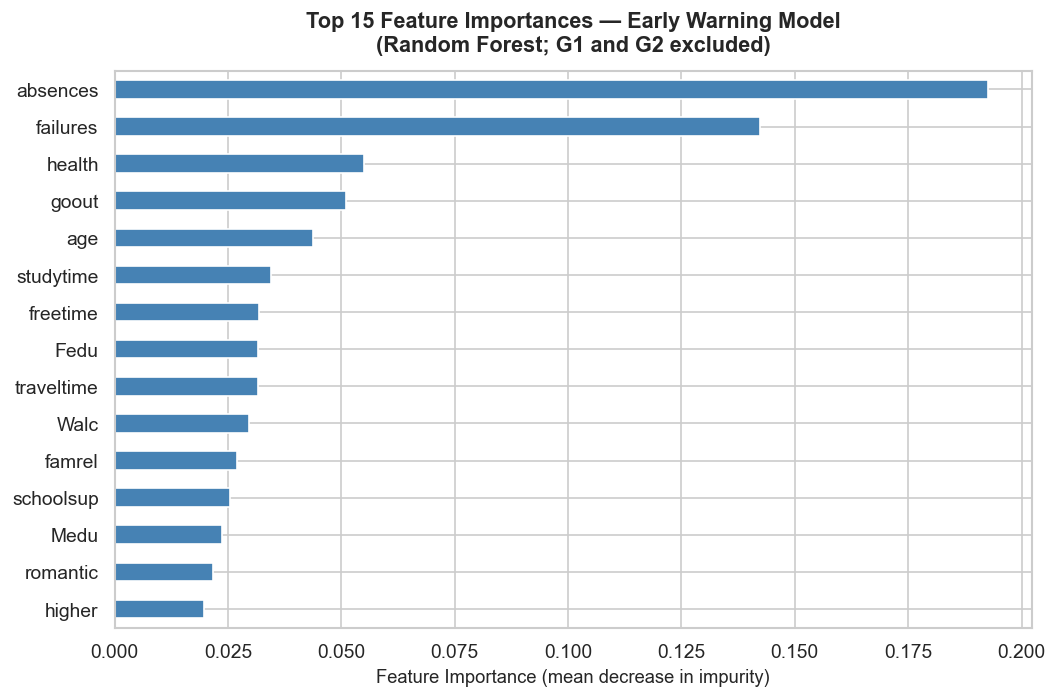

Top 15 feature importances:
absences      0.1926
failures      0.1424
health        0.0550
goout         0.0511
age           0.0437
studytime     0.0345
freetime      0.0318
Fedu          0.0317
traveltime    0.0316
Walc          0.0297
famrel        0.0271
schoolsup     0.0255
Medu          0.0238
romantic      0.0216
higher        0.0196


In [19]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top15.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 15 Feature Importances — Early Warning Model\n'
             '(Random Forest; G1 and G2 excluded)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Feature Importance (mean decrease in impurity)', fontsize=11)
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('figures/chart_ml_feature_importances.png')
plt.show()

print('Top 15 feature importances:')
print(top15.round(4).to_string())

**Observation — Feature Importances:** The model assigned the highest importance scores to the features listed and printed above. Features that showed the strongest associations with G3 in the EDA (failures, Medu, studytime) are expected to appear among the highest-ranked features, which would indicate consistency between the model's internal weightings and the exploratory findings.

> **Important:** Feature importances are the model's internal weightings in this specific model on this specific dataset. They reflect how much each variable reduces prediction error in the Random Forest. They are not validated causal relationships.

### Sensitivity Analysis — Effect of G3 = 0 Records

The 38 students with G3 = 0 form a pattern distinct from the main distribution. This analysis shows how model metrics change when those records are excluded. The main model above includes all 395 rows; this is supplementary.

In [20]:
mask_nonzero = y != 0
X_nz = X[mask_nonzero]
y_nz = y[mask_nonzero]
print(f'Rows after excluding G3=0: {len(y_nz)} (removed {(~mask_nonzero).sum()} rows)')

kf_nz = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_sens = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)

cv_rmse_nz = np.sqrt(-cross_val_score(
    rf_sens, X_nz, y_nz, cv=kf_nz, scoring='neg_mean_squared_error'
))
cv_r2_nz = cross_val_score(rf_sens, X_nz, y_nz, cv=kf_nz, scoring='r2')

print('\n── Sensitivity Analysis: Cross-Validation Comparison ──')
print(f'                          RMSE              R²')
print(f'  Full dataset (n=395):   {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}   {cv_r2.mean():.3f} ± {cv_r2.std():.3f}')
print(f'  Excl. G3=0   (n={len(y_nz)}):  {cv_rmse_nz.mean():.3f} ± {cv_rmse_nz.std():.3f}   {cv_r2_nz.mean():.3f} ± {cv_r2_nz.std():.3f}')
print(f'\n  RMSE change: {cv_rmse_nz.mean() - cv_rmse.mean():+.3f}')
print(f'  R² change:   {cv_r2_nz.mean() - cv_r2.mean():+.3f}')

Rows after excluding G3=0: 357 (removed 38 rows)



── Sensitivity Analysis: Cross-Validation Comparison ──
                          RMSE              R²
  Full dataset (n=395):   3.819 ± 0.238   0.293 ± 0.040
  Excl. G3=0   (n=357):  2.911 ± 0.160   0.179 ± 0.049

  RMSE change: -0.909
  R² change:   -0.114


**Observation — Sensitivity Analysis:** The comparison table above shows how 5-fold cross-validated RMSE and R² change when the 38 G3 = 0 records are excluded. A decrease in RMSE when those records are removed would indicate that predicting their outcomes is particularly difficult and that they are inflating the overall error measure. The direction and magnitude of the change (printed above) show the extent to which those records influence model performance. This should be considered when interpreting the main model results.

### G1 and G2 Leakage Note

> If G1 and G2 were included as features, the model would achieve a substantially higher R² — because G2 alone has a Pearson correlation of approximately 0.905 with G3. However, that model would only be applicable after period grades are already known, making it unsuitable as an early-warning tool. The purpose of this model is to identify at-risk students *before* any grades are issued. A high R² achieved through period grades would primarily measure the consistency of the grading system, not the model's utility for early intervention.

---

## Summary

| Section | Key Output |
|---|---|
| Data Inspection | 395 rows × 33 cols; complete; G3=0 in 38 rows (all with non-zero G1, cause undocumented); absences right-skewed |
| EDA | 6 charts: G3 distribution, failures box plot, study time box plot, maternal education bar, absences scatter, correlation heatmap |
| Observations | 6 factual data observations (including that absences have near-zero linear correlation with G3) |
| Insights | 5 associational patterns |
| Hypotheses | 3 testable explanations |
| Recommendations | 5 evidence-labelled practical actions |
| ML Model | Random Forest early-warning model (G1/G2 excluded); 5-fold CV; sensitivity analysis on G3=0 rows |
| Charts saved | `figures/` directory — 7 PNG files |